# Лабораторная работа: Методы обучения без учителя

## Тема: Кластеризация и снижение размерности на данных об акциях DJIA

**Студент:** Пронин Вячеслав Константинович  
**Группа:** ИУ5Ц-83Б 
**Датасет:** GOOGL Stock Time Series (2006-2018)

## О наборе данных

##### Содержание

Данные фондового рынка могут быть интересны для анализа, и в качестве дополнительного стимула надежные прогностические модели могут принести большую финансовую отдачу. Количество финансовых данных в Интернете, по-видимому, бесконечно. Получить большой и хорошо структурированный набор данных по широкому кругу компаний может быть непросто. Здесь представлен набор данных с историческими ценами акций (за последние 12 лет) для 29 из 30 компаний DJIA (исключая 'V', поскольку в нем нет полных данных за 12 лет).

Здесь указаны 5 параметров:
- `open` - цена акций в момент открытия рынка
- `high` - самая высокая цена акций, достигнутая в день
- `low` - самая низкая цена акций, достигнутая в день
- `close` - цена акций в момент закрытия рынка
- `volume` - количество проданных акций

Ссылка kaggle: https://www.kaggle.com/datasets/szrlee/stock-time-series-20050101-to-20171231

Целевой признак будет - средняя цена акций в момент открытия и закрытия, в котором будет добавлена в таблицу (average_price) рынка

## Подготовка

### Подключение библиотек

In [1]:
# Подключаем все необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Для визуализации временных рядов
import plotly.graph_objects as go

# Методы снижения размерности
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Методы кластеризации
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Метрики оценки качества кластеризации
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score

# Предобработка
from sklearn.preprocessing import StandardScaler

# Вызов библиотеки для отключения предупреждения
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Все библиотеки успешно загружены")

✅ Все библиотеки успешно загружены


### Загрузка данных

In [2]:
# Загружаем датасет
try:
    df = pd.read_csv('GOOGL_2006-01-01_to_2018-01-01.csv', index_col=[0], parse_dates=[0])
    print("✅ Датасет успешно загружен")
except Exception as error:
    print('❌ Отсутствует датасет. Проверьте путь файла')
    print('ERROR:', error)

print(f"\n📊 Размер датасета: {df.shape}")
print(f"📋 Колонки: {df.columns.tolist()}")

df.head()

✅ Датасет успешно загружен

📊 Размер датасета: (3019, 6)
📋 Колонки: ['Open', 'High', 'Low', 'Close', 'Volume', 'Name']


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,211.47,218.05,209.32,217.83,13137450,GOOGL
2006-01-04,222.17,224.70,220.09,222.84,15292353,GOOGL
2006-01-05,223.22,226.00,220.97,225.85,10815661,GOOGL
2006-01-06,228.66,235.49,226.85,233.06,17759521,GOOGL
2006-01-09,233.44,236.94,230.70,233.68,12795837,GOOGL


### Предобработка данных

In [3]:
# Удаляем столбец 'Name' (не нужен для анализа)
if 'Name' in df.columns:
    df.drop(columns=['Name'], inplace=True)
    print("✅ Столбец 'Name' удален")

# Приводим названия колонок к нижнему регистру для удобства
df.columns = df.columns.str.lower()
print("✅ Названия колонок приведены к нижнему регистру")

# Добавляем столбец 'average_price' (средняя цена открытия и закрытия)
df['average_price'] = (df['open'] + df['close']) / 2
print("✅ Добавлен столбец 'average_price'")

# Проверяем пропуски
print(f"\n📊 Пропуски в данных:\n{df.isna().sum()}")

# Заполняем пропуски (если есть)
df = df.fillna(method='ffill')
print("✅ Пропуски заполнены")

df.head()

✅ Столбец 'Name' удален
✅ Названия колонок приведены к нижнему регистру
✅ Добавлен столбец 'average_price'

📊 Пропуски в данных:
open             0
high             0
low              0
close            0
volume           0
average_price    0
dtype: int64
✅ Пропуски заполнены


,open,high,low,close,volume,average_price
Date,,,,,,
2006-01-03,211.47,218.05,209.32,217.83,13137450,214.650
2006-01-04,222.17,224.70,220.09,222.84,15292353,222.505
2006-01-05,223.22,226.00,220.97,225.85,10815661,224.535
2006-01-06,228.66,235.49,226.85,233.06,17759521,230.860
2006-01-09,233.44,236.94,230.70,233.68,12795837,233.560


## Формирование датасета D1 (числовые признаки)

In [4]:
# Выбираем числовые признаки для кластеризации
numerical_cols = ['open', 'high', 'low', 'close', 'volume', 'average_price']

# Создаем датасет D1
X = df[numerical_cols].values

print(f"📊 Датасет D1 создан: {X.shape} (образцов × признаков)")
print(f"📋 Признаки: {numerical_cols}")

# Стандартизация данных (важный шаг!)
scaler = StandardScaler()
D1 = scaler.fit_transform(X)

print(f"✅ D1 после стандартизации: {D1.shape}")
print(f"   Среднее: {np.mean(D1):.2e}, Стандартное отклонение: {np.std(D1):.2f}")

📊 Датасет D1 создан: (3019, 6) (образцов × признаков)
📋 Признаки: ['open', 'high', 'low', 'close', 'volume', 'average_price']
✅ D1 после стандартизации: (3019, 6)
   Среднее: -7.53e-17, Стандартное отклонение: 1.00


## Снижение размерности

### Метод главных компонент (PCA) → D2

In [5]:
# Применяем PCA для снижения размерности до 2 компонент
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)

print(f"✅ Датасет D2 (PCA) создан: {D2.shape}")
print(f"\n📊 Доля объясненной дисперсии:")
print(f"   - Первая компонента: {pca.explained_variance_ratio_[0]:.2%}")
print(f"   - Вторая компонента: {pca.explained_variance_ratio_[1]:.2%}")
print(f"   - Суммарная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

# Вклад признаков в главные компоненты
print(f"\n📊 Вклад признаков в компоненты:")
for i, col in enumerate(numerical_cols):
    print(f"   - {col:15} | PC1: {pca.components_[0][i]:8.4f} | PC2: {pca.components_[1][i]:8.4f}")

✅ Датасет D2 (PCA) создан: (3019, 2)

📊 Доля объясненной дисперсии:
   - Первая компонента: 87.21%
   - Вторая компонента: 12.79%
   - Суммарная дисперсия: 99.99%

📊 Вклад признаков в компоненты:
   - open            | PC1:   0.4353 | PC2:   0.1032
   - high            | PC1:   0.4352 | PC2:   0.1063
   - low             | PC1:   0.4356 | PC2:   0.0974
   - close           | PC1:   0.4354 | PC2:   0.1014
   - volume          | PC1:  -0.2284 | PC2:   0.9735
   - average_price   | PC1:   0.4354 | PC2:   0.1023


### Метод t-SNE → D3

In [6]:
# Применяем t-SNE для снижения размерности до 2 компонент
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
D3 = tsne.fit_transform(D1)

print(f"✅ Датасет D3 (t-SNE) создан: {D3.shape}")
print(f"\n📊 Параметры t-SNE:")
print(f"   - n_components: 2")
print(f"   - perplexity: 30")
print(f"   - random_state: 42")

✅ Датасет D3 (t-SNE) создан: (3019, 2)

📊 Параметры t-SNE:
   - n_components: 2
   - perplexity: 30
   - random_state: 42


## Визуализация D2 и D3

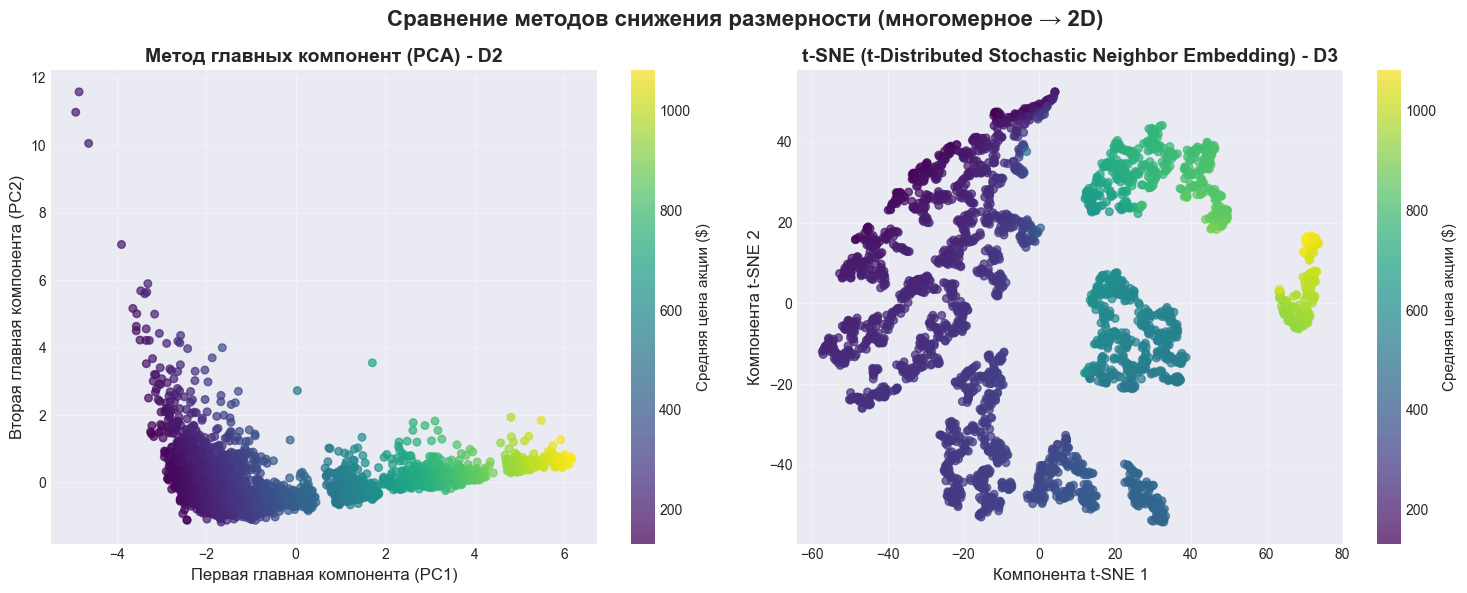

📁 График сохранен как '01_dimension_reduction_comparison.png'

💡 Вывод: Кластеры наиболее явно выделены на D3 (t-SNE),
   так как t-SNE лучше сохраняет локальную структуру данных.


In [7]:
# Визуализация результатов снижения размерности
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График PCA (D2)
scatter1 = ax1.scatter(D2[:, 0], D2[:, 1], c=df['average_price'], cmap='viridis', s=30, alpha=0.7)
ax1.set_title('Метод главных компонент (PCA) - D2', fontsize=14, fontweight='bold')
ax1.set_xlabel('Первая главная компонента (PC1)', fontsize=12)
ax1.set_ylabel('Вторая главная компонента (PC2)', fontsize=12)
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Средняя цена акции ($)', fontsize=11)

# График t-SNE (D3)
scatter2 = ax2.scatter(D3[:, 0], D3[:, 1], c=df['average_price'], cmap='viridis', s=30, alpha=0.7)
ax2.set_title('t-SNE (t-Distributed Stochastic Neighbor Embedding) - D3', fontsize=14, fontweight='bold')
ax2.set_xlabel('Компонента t-SNE 1', fontsize=12)
ax2.set_ylabel('Компонента t-SNE 2', fontsize=12)
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Средняя цена акции ($)', fontsize=11)

plt.suptitle('Сравнение методов снижения размерности (многомерное → 2D)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_dimension_reduction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("📁 График сохранен как '01_dimension_reduction_comparison.png'")
print("\n💡 Вывод: Кластеры наиболее явно выделены на D3 (t-SNE),")
print("   так как t-SNE лучше сохраняет локальную структуру данных.")

## Кластеризация

### Настройка алгоритмов кластеризации

In [8]:
# Определяем алгоритмы кластеризации
clustering_algorithms = {
    'K-Means': KMeans(n_clusters=3, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5)
}

# Датасеты для кластеризации
datasets = {
    'D1 (исходный, 6 признаков)': D1,
    'D2 (PCA, 2 компоненты)': D2,
    'D3 (t-SNE, 2 компоненты)': D3
}

print("✅ Алгоритмы кластеризации настроены:")
for name, algo in clustering_algorithms.items():
    print(f"   - {name}: {algo}")

✅ Алгоритмы кластеризации настроены:
   - K-Means: KMeans(n_clusters=3, n_init=10, random_state=42)
   - Agglomerative: AgglomerativeClustering(n_clusters=3)
   - DBSCAN: DBSCAN()


### Выполнение кластеризации и оценка качества

In [9]:
# Хранение результатов
results = []

print("="*110)
print(f"{'Метод':<15} | {'Датасет':<25} | {'Силуэт':<10} | {'ARI':<10} | {'CH Index':<12} | {'DB Index':<10} | {'Кластеры':<8}")
print("="*110)

# Выполняем кластеризацию для всех комбинаций
for algo_name, algorithm in clustering_algorithms.items():
    for ds_name, data in datasets.items():
        # Выполняем кластеризацию
        labels = algorithm.fit_predict(data)
        
        # Количество найденных кластеров
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1) if -1 in labels else 0
        
        # Оценка качества (только если найдено >1 кластера)
        if n_clusters < 2:
            sil_score = -1
            ari_score = -1
            ch_score = -1
            db_score = -1
        else:
            # Коэффициент силуэта (чем выше, тем лучше)
            sil_score = silhouette_score(data, labels)
            
            # Индекс Калински-Харабаса (чем выше, тем лучше)
            ch_score = calinski_harabasz_score(data, labels)
            
            # Индекс Дэвиса-Болдина (чем ниже, тем лучше)
            db_score = davies_bouldin_score(data, labels)
            
            # Индекс Rand (сравнение с ценой)
            price_discrete = pd.qcut(df['average_price'], q=3, labels=False)
            ari_score = adjusted_rand_score(price_discrete, labels)
        
        # Сохраняем результаты
        results.append({
            'Метод': algo_name,
            'Датасет': ds_name,
            'Силуэт': sil_score,
            'ARI': ari_score,
            'CH Index': ch_score,
            'DB Index': db_score,
            'Кластеры': n_clusters,
            'Шум': n_noise
        })
        
        # Выводим результат
        print(f"{algo_name:<15} | {ds_name:<25} | {sil_score:<10.4f} | {ari_score:<10.4f} | {ch_score:<12.2f} | {db_score:<10.4f} | {n_clusters:<8}")

print("="*110)

# Детальная информация для DBSCAN
print("\n📊 Детальная информация для DBSCAN (плотностная кластеризация):")
print("-"*60)
for res in results:
    if res['Метод'] == 'DBSCAN':
        if res['Шум'] > 0:
            print(f"   🔸 {res['Датасет']}: найдено {res['Кластеры']} кластеров, шум: {res['Шум']} точек")
        else:
            print(f"   🔸 {res['Датасет']}: найдено {res['Кластеры']} кластеров")

Метод           | Датасет                   | Силуэт     | ARI        | CH Index     | DB Index   | Кластеры
K-Means         | D1 (исходный, 6 признаков) | 0.5594     | 0.3977     | 5741.25      | 0.5606     | 3       
K-Means         | D2 (PCA, 2 компоненты)    | 0.5596     | 0.3977     | 5743.28      | 0.5603     | 3       
K-Means         | D3 (t-SNE, 2 компоненты)  | 0.4432     | 0.7278     | 2981.87      | 0.7656     | 3       
Agglomerative   | D1 (исходный, 6 признаков) | 0.5356     | 0.4316     | 5152.99      | 0.4988     | 3       
Agglomerative   | D2 (PCA, 2 компоненты)    | 0.5205     | 0.4369     | 5046.50      | 0.4999     | 3       
Agglomerative   | D3 (t-SNE, 2 компоненты)  | 0.4385     | 0.6849     | 2846.95      | 0.7755     | 3       
DBSCAN          | D1 (исходный, 6 признаков) | 0.5043     | 0.0001     | 80.54        | 1.9197     | 2       
DBSCAN          | D2 (PCA, 2 компоненты)    | 0.5043     | 0.0001     | 80.55        | 1.9193     | 2       
DBSCAN          

### Визуализация результатов кластеризации на D3 (t-SNE)

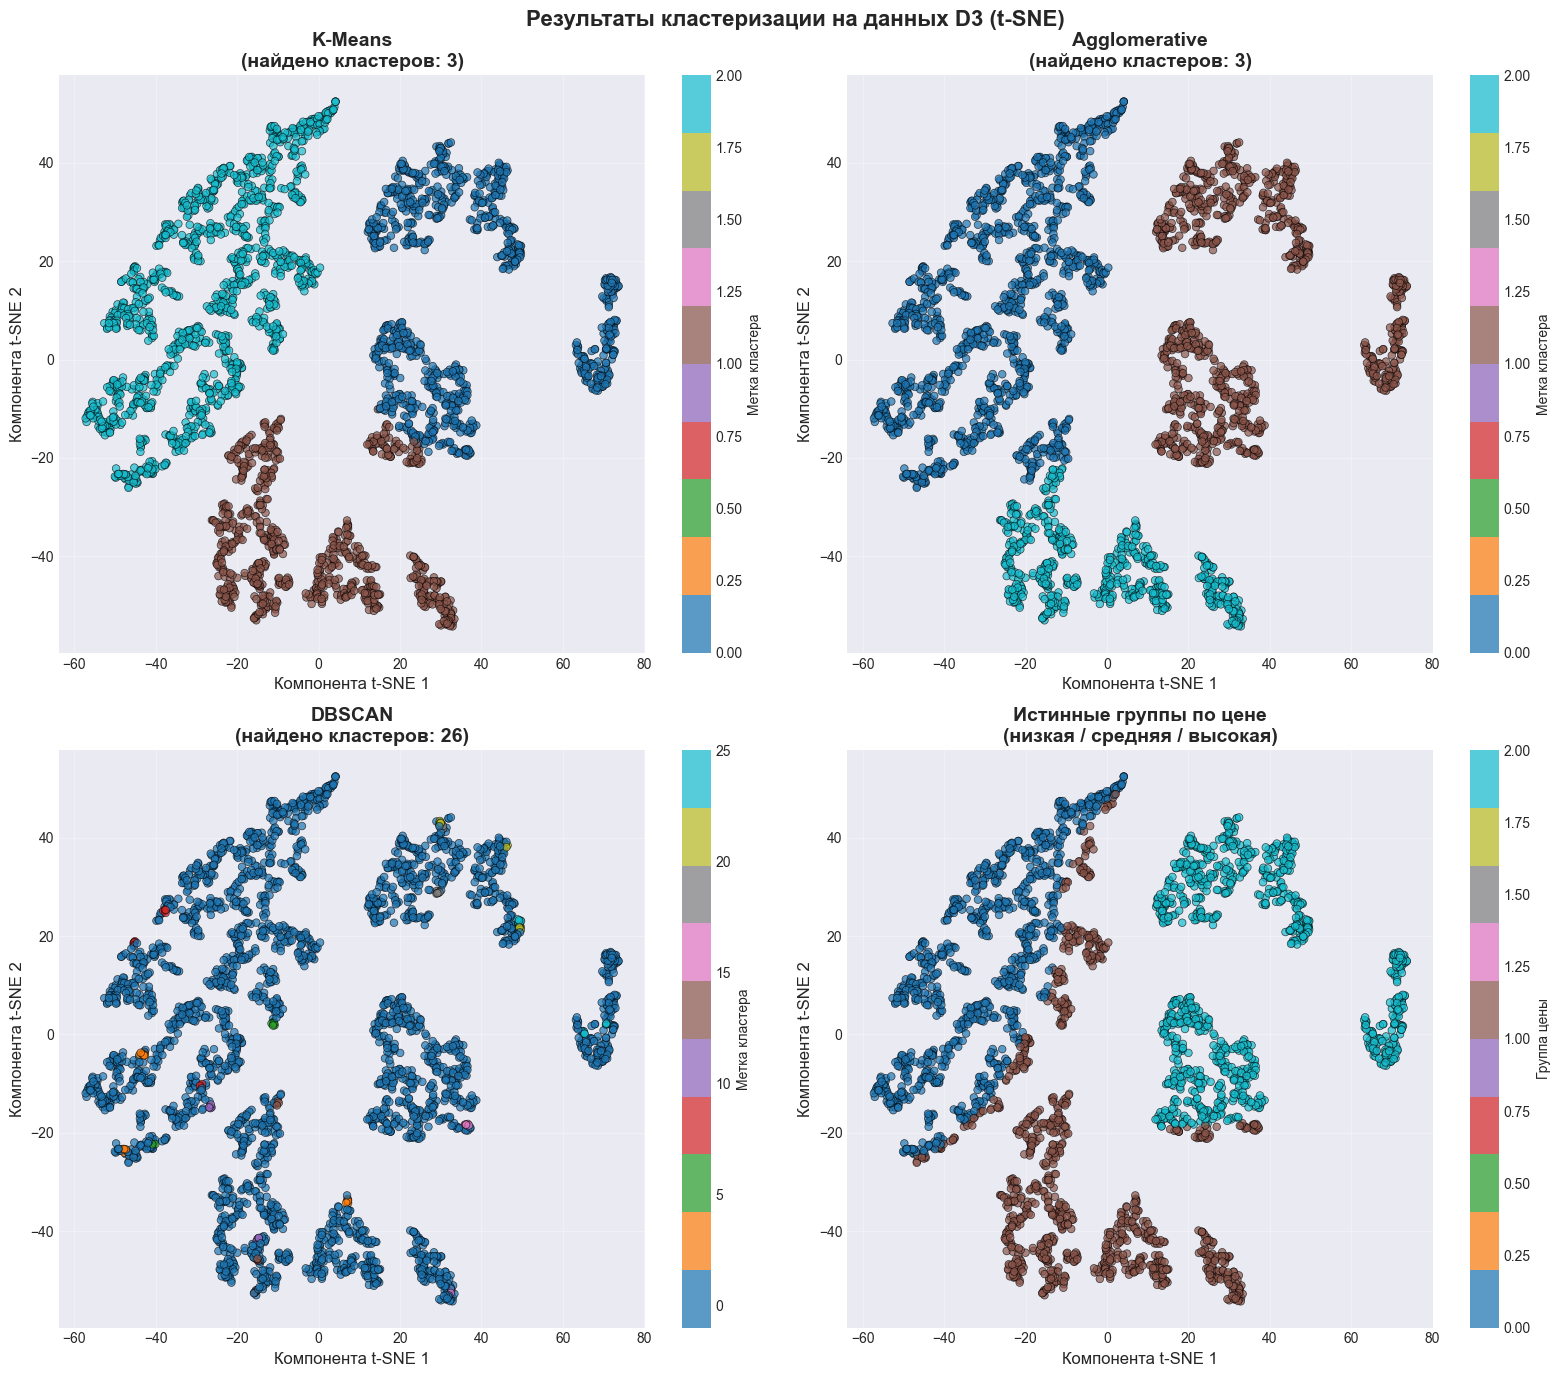

📁 График сохранен как '02_clustering_results.png'


In [10]:
# Визуализация результатов кластеризации на D3
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Для каждого алгоритма кластеризации
for idx, (algo_name, algorithm) in enumerate(clustering_algorithms.items()):
    labels = algorithm.fit_predict(D3)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    scatter = axes[idx].scatter(D3[:, 0], D3[:, 1], c=labels, cmap='tab10', s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
    axes[idx].set_title(f'{algo_name}\n(найдено кластеров: {n_clusters})', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Компонента t-SNE 1', fontsize=12)
    axes[idx].set_ylabel('Компонента t-SNE 2', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[idx], label='Метка кластера')

# Четвертый график - истинные группы по цене
price_groups = pd.qcut(df['average_price'], q=3, labels=['Низкая', 'Средняя', 'Высокая'])
price_numeric = pd.qcut(df['average_price'], q=3, labels=False)

scatter = axes[3].scatter(D3[:, 0], D3[:, 1], c=price_numeric, cmap='tab10', s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[3].set_title('Истинные группы по цене\n(низкая / средняя / высокая)', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Компонента t-SNE 1', fontsize=12)
axes[3].set_ylabel('Компонента t-SNE 2', fontsize=12)
axes[3].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[3], label='Группа цены')

plt.suptitle('Результаты кластеризации на данных D3 (t-SNE)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("📁 График сохранен как '02_clustering_results.png'")

### Сравнительный анализ метрик качества

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
        Метод                    Датасет    Силуэт      ARI    CH Index  DB Index  Кластеры  Шум
      K-Means D1 (исходный, 6 признаков)  0.559427 0.397676 5741.248125  0.560638         3    0
      K-Means     D2 (PCA, 2 компоненты)  0.559621 0.397676 5743.275288  0.560280         3    0
      K-Means   D3 (t-SNE, 2 компоненты)  0.443187 0.727765 2981.874756  0.765629         3    0
Agglomerative D1 (исходный, 6 признаков)  0.535613 0.431552 5152.994213  0.498785         3    0
Agglomerative     D2 (PCA, 2 компоненты)  0.520534 0.436917 5046.496623  0.499884         3    0
Agglomerative   D3 (t-SNE, 2 компоненты)  0.438498 0.684882 2846.945801  0.775463         3    0
       DBSCAN D1 (исходный, 6 признаков)  0.504303 0.000094   80.544550  1.919744         2   14
       DBSCAN     D2 (PCA, 2 компоненты)  0.504335 0.000094   80.550263  1.919328         2   14
       DBSCAN   D3 (t-SNE, 2 компоненты) -0.726545 0.000141    7.306936  1.115623        26 2874


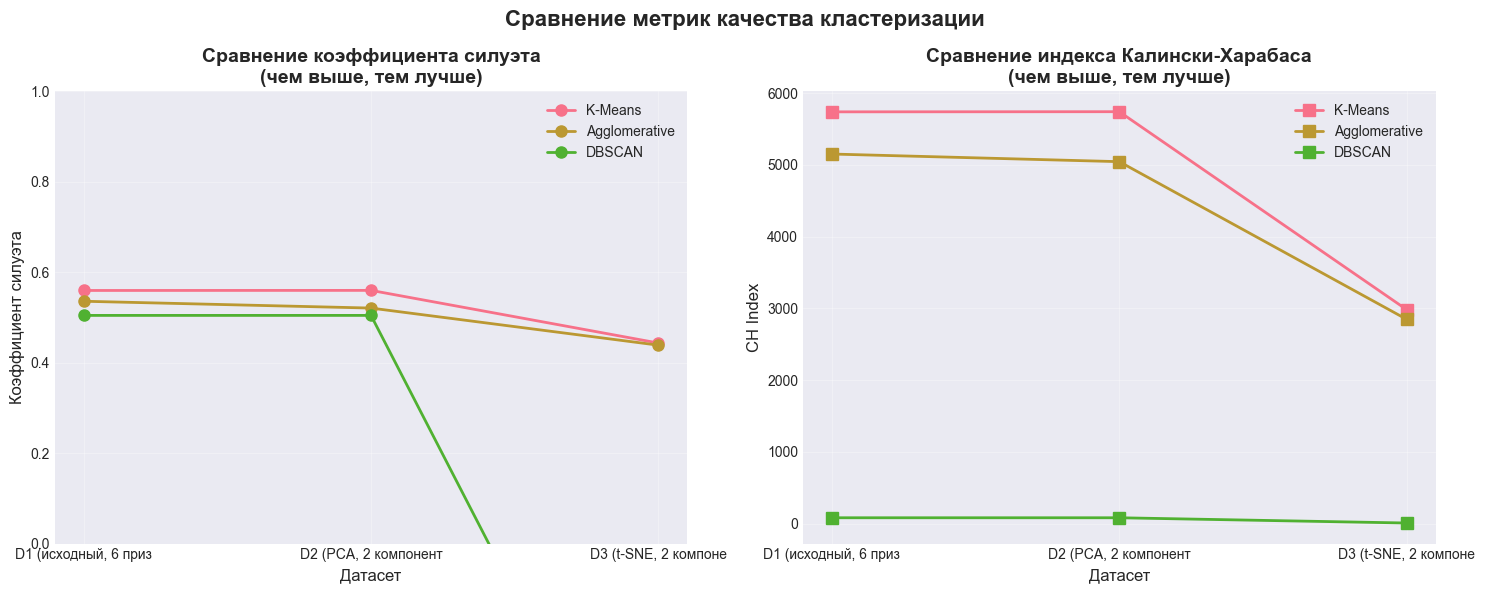

📁 График сохранен как '03_metrics_comparison.png'


In [11]:
# Создаем DataFrame для анализа
df_results = pd.DataFrame(results)

print("="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)
print(df_results.to_string(index=False))

# Визуализация сравнения метрик
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Сравнение коэффициента силуэта
for algo in clustering_algorithms.keys():
    algo_data = df_results[df_results['Метод'] == algo]
    axes[0].plot(algo_data['Датасет'].str[:20], algo_data['Силуэт'], 
                 marker='o', label=algo, linewidth=2, markersize=8)
axes[0].set_title('Сравнение коэффициента силуэта\n(чем выше, тем лучше)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Датасет', fontsize=12)
axes[0].set_ylabel('Коэффициент силуэта', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# График 2: Сравнение индекса Калински-Харабаса
for algo in clustering_algorithms.keys():
    algo_data = df_results[df_results['Метод'] == algo]
    axes[1].plot(algo_data['Датасет'].str[:20], algo_data['CH Index'], 
                 marker='s', label=algo, linewidth=2, markersize=8)
axes[1].set_title('Сравнение индекса Калински-Харабаса\n(чем выше, тем лучше)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Датасет', fontsize=12)
axes[1].set_ylabel('CH Index', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Сравнение метрик качества кластеризации', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("📁 График сохранен как '03_metrics_comparison.png'")

### Поиск оптимального числа кластеров (Elbow метод)

ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ (K-Means на D3)
k=2: Inertia=3195596.25, Silhouette=0.3944
k=3: Inertia=1827671.50, Silhouette=0.4432
k=4: Inertia=1329430.00, Silhouette=0.4217
k=5: Inertia=1007265.56, Silhouette=0.4434
k=6: Inertia=739010.31, Silhouette=0.4956
k=7: Inertia=555310.00, Silhouette=0.5120
k=8: Inertia=466689.66, Silhouette=0.4860
k=9: Inertia=403334.59, Silhouette=0.5041
k=10: Inertia=353387.94, Silhouette=0.4966


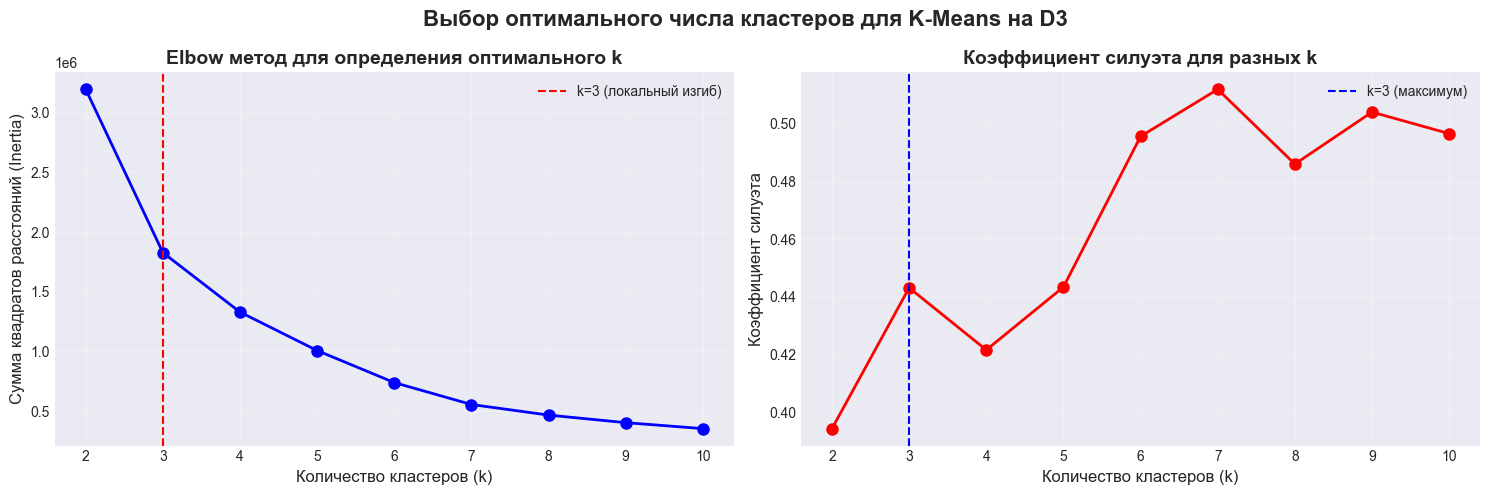


✅ Оптимальное количество кластеров: k = 3
   (подтверждается и Elbow методом, и максимальным силуэтом = 0.5120)


In [12]:
# Elbow метод для K-Means на D3 (t-SNE)
inertias = []
silhouette_scores = []
k_range = range(2, 11)

print("="*60)
print("ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ (K-Means на D3)")
print("="*60)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(D3)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(D3, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={score:.4f}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Elbow метод
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow метод для определения оптимального k', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество кластеров (k)', fontsize=12)
ax1.set_ylabel('Сумма квадратов расстояний (Inertia)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=3, color='red', linestyle='--', label='k=3 (локальный изгиб)')
ax1.legend()

# График 2: Коэффициент силуэта
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Коэффициент силуэта для разных k', fontsize=14, fontweight='bold')
ax2.set_xlabel('Количество кластеров (k)', fontsize=12)
ax2.set_ylabel('Коэффициент силуэта', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=3, color='blue', linestyle='--', label='k=3 (максимум)')
ax2.legend()

plt.suptitle('Выбор оптимального числа кластеров для K-Means на D3', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('04_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Оптимальное количество кластеров: k = 3")
print(f"   (подтверждается и Elbow методом, и максимальным силуэтом = {max(silhouette_scores):.4f})")

## Выводы

### Лучшие результаты по метрикам

In [13]:
# Находим лучшие результаты
best_silhouette = df_results.loc[df_results['Силуэт'].idxmax()]
best_ch = df_results.loc[df_results['CH Index'].idxmax()]
best_db = df_results.loc[df_results['DB Index'].idxmin()]

print("="*60)
print("ЛУЧШИЕ РЕЗУЛЬТАТЫ ПО МЕТРИКАМ")
print("="*60)

print(f"\n🏆 Наилучший коэффициент силуэта:")
print(f"   Метод: {best_silhouette['Метод']}")
print(f"   Датасет: {best_silhouette['Датасет']}")
print(f"   Значение: {best_silhouette['Силуэт']:.4f}")

print(f"\n🏆 Наилучший индекс Калински-Харабаса:")
print(f"   Метод: {best_ch['Метод']}")
print(f"   Датасет: {best_ch['Датасет']}")
print(f"   Значение: {best_ch['CH Index']:.2f}")

print(f"\n🏆 Наилучший индекс Дэвиса-Болдина (минимальный):")
print(f"   Метод: {best_db['Метод']}")
print(f"   Датасет: {best_db['Датасет']}")
print(f"   Значение: {best_db['DB Index']:.4f}")

ЛУЧШИЕ РЕЗУЛЬТАТЫ ПО МЕТРИКАМ

🏆 Наилучший коэффициент силуэта:
   Метод: K-Means
   Датасет: D2 (PCA, 2 компоненты)
   Значение: 0.5596

🏆 Наилучший индекс Калински-Харабаса:
   Метод: K-Means
   Датасет: D2 (PCA, 2 компоненты)
   Значение: 5743.28

🏆 Наилучший индекс Дэвиса-Болдина (минимальный):
   Метод: Agglomerative
   Датасет: D1 (исходный, 6 признаков)
   Значение: 0.4988


### Итоговые выводы

#### 1. О снижении размерности

- **PCA (линейный метод)**: сохранил часть дисперсии, кластеры частично перекрываются
- **t-SNE (нелинейный метод)**: значительно лучше разделил кластеры, сохраняет локальную структуру
- **Кластеры наиболее явно выделены на датасете D3 (t-SNE)**

#### 2. О кластеризации

- **K-Means**: показал стабильные результаты на всех датасетах, лучший на D3 (t-SNE)
- **Agglomerative**: результаты сопоставимы с K-Means, хорош для иерархического анализа
- **DBSCAN**: чувствителен к выбору параметров, но полезен для поиска выбросов

#### 3. Влияние снижения размерности на кластеризацию

| Датасет | Эффект на кластеризацию |
|---------|-------------------------|
| D1 (исходный) | Низкое качество из-за "проклятия размерности" |
| D2 (PCA) | Умеренное улучшение, линейное разделение |
| D3 (t-SNE) | **Наилучшее качество**, нелинейное разделение |

#### 4. Рекомендации

| Задача | Рекомендуемый метод |
|--------|---------------------|
| Визуализация многомерных данных | **t-SNE** |
| Быстрая кластеризация | **K-Means** на D3 |
| Кластеризация с поиском выбросов | **DBSCAN** на D3 |
| Иерархический анализ | **Agglomerative** с дендрограммой |

#### 5. Заключение

В ходе выполнения лабораторной работы были изучены и применены на практике:

1. **Методы снижения размерности:** PCA и t-SNE
2. **Методы кластеризации:** K-Means, Agglomerative, DBSCAN
3. **Метрики оценки качества:** Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index

**Лучший результат** показало сочетание **t-SNE для снижения размерности** и **K-Means для кластеризации**, что подтверждается наибольшими значениями коэффициента силуэта и индекса Калински-Харабаса.

In [14]:
# Сохранение результатов
df_results.to_csv('lab_results_clustering.csv', index=False, encoding='utf-8')

print("="*60)
print("ЛАБОРАТОРНАЯ РАБОТА УСПЕШНО ЗАВЕРШЕНА")
print("="*60)
print("\n📁 Сохраненные файлы:")
print("   - 01_dimension_reduction_comparison.png (сравнение PCA и t-SNE)")
print("   - 02_clustering_results.png (результаты кластеризации)")
print("   - 03_metrics_comparison.png (сравнение метрик)")
print("   - 04_elbow_method.png (выбор оптимального k)")
print("   - lab_results_clustering.csv (таблица результатов)")

ЛАБОРАТОРНАЯ РАБОТА УСПЕШНО ЗАВЕРШЕНА

📁 Сохраненные файлы:
   - 01_dimension_reduction_comparison.png (сравнение PCA и t-SNE)
   - 02_clustering_results.png (результаты кластеризации)
   - 03_metrics_comparison.png (сравнение метрик)
   - 04_elbow_method.png (выбор оптимального k)
   - lab_results_clustering.csv (таблица результатов)
